## Problem 1 - Linear Heat Conduction

as something that i always felt its lack in the pamplets and books throughout my academic journey, i always try to state very simple, short and clear at the very first of each report or assighnment that what we are doing, why and how.
so in this problem we solve $-k\frac{d^2T}{dx^2}=0$ using __finite volume method__ to obtain __the temperature of each point__ throughout the bar.

now time to dive into it. we are solving the steady one-dimensional heat conduction equation for a titanium square bar. The end temperatures are fixed at 100°C and 0°C. Since the convection coefficient (h) on the exposed surfaces is zero, there is no heat loss from the sides of the bar, as well as heat generation inside the bar.

The governing equation for steady heat conduction is:

$$ - k\nabla^2T - S = 0 $$

since this is a case of 1D condoction with no internal source, the governing equation will turn to:


$$
-k\frac{d^2T}{dx^2}=0
$$

Since \(k\) is constant:

$$
\frac{d^2T}{dx^2}=0
$$

Therefore, the analytical solution is linear:

$$
T(x)=T_1+\frac{T_2-T_1}{L}x
$$

The square bar dimensions as given in the problem 1:

$$
L_x = 1.0 \text{ m}
$$

$$
L_y = L_z = 0.1 \text{ m}
$$
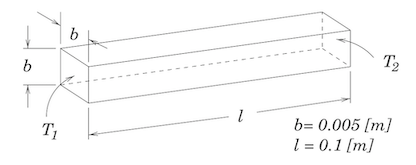

The thermal conductivity of titanium is:

$$
k = 21.9 \text{ W/m}\cdot\text{K}
$$



## Grid Definition

The following class defines the one-dimensional Cartesian computational grid used for the finite-volume discretization. The class stores the control volume geometry, face locations, cell-center locations, face areas, and cell volumes.

In [8]:
import numpy as np

class Grid:
    """Class defining a one-dimensional Cartesian grid"""
    
    def __init__(self, lx, ly, lz, ncv):
        """Constructor
            lx .... total length of domain in x-direction [m]
            ly .... total length of domain in y-direction [m]
            lz .... total length of domain in z-direction [m]
            ncv ... number of control volumes in domain
        """
        # Store the number of control volumes
        self._ncv = ncv
        
        # Calculate the control volume length
        dx = lx/float(ncv)
        
        # Calculate the face locations
        self._xf = np.array([i*dx for i in range(ncv+1)])
        
        # Calculate the cell centroid locations
        self._xP = np.array([self._xf[0]] + 
                            [0.5*(self._xf[i]+self._xf[i+1]) for i in range(ncv)] +
                            [self._xf[-1]])
        
        # Calculate face areas
        self._Af = ly*lz*np.ones(ncv+1)
        
        # Calculate the outer surface area for each cell
        self._Ao = (2.0*dx*ly + 2.0*dx*lz)*np.ones(ncv)
        
        # Calculate cell volumes
        self._vol = dx*ly*lz*np.ones(ncv)
        
    @property
    def ncv(self):
        """Number of control volumes in domain"""
        return self._ncv
    
    @property
    def xf(self):
        """Face location array"""
        return self._xf
    
    @property
    def xP(self):
        """Cell centroid array"""
        return self._xP
    
    @property
    def dx_WP(self):
        return self.xP[1:-1]-self.xP[0:-2]
        
    @property
    def dx_PE(self):
        return self.xP[2:]-self.xP[1:-1]
      
    @property
    def Af(self):
        """Face area array"""
        return self._Af

    @property
    def Aw(self):
        """West face area array"""
        return self._Af[0:-1]
    
    @property
    def Ae(self):
        """East face area array"""
        return self._Af[1:]
    
    @property
    def Ao(self):
        """Outer face area array"""
        return self._Ao
    
    @property
    def vol(self):
        """Cell volume array"""
        return self._vol

## Finite-Volume Coefficients

The following class defines the coefficient arrays used in the finite-volume discretization. The coefficients correspond to the neighboring control volumes and are used to assemble the linear algebraic system.

In [9]:
class ScalarCoeffs:
    """Class defining the set of coefficients for a finite-volume discretization
       of a scalar partial differential equation.
    """
    
    def __init__(self, ncv):
        """Constructor
            ncv ... number of control volumes in domain
        """
        self._ncv = ncv
        self._aP = np.zeros(ncv)
        self._aW = np.zeros(ncv)
        self._aE = np.zeros(ncv)
        self._rP = np.zeros(ncv)
        
    def zero(self):
        """Function to zero the coefficient arrays"""
        self._aP.fill(0.0)
        self._aW.fill(0.0)
        self._aE.fill(0.0)
        self._rP.fill(0.0)
        
    def accumulate_aP(self, aP):
        """Function to accumulate values onto aP"""
        self._aP += aP
        
    def accumulate_aW(self, aW):
        """Function to accumulate values onto aW"""
        self._aW += aW

    def accumulate_aE(self, aE):
        """Function to accumulate values onto aE"""
        self._aE += aE
        
    def accumulate_rP(self, rP):
        """Function to accumulate values onto rP"""
        self._rP += rP
        
    @property
    def ncv(self):
        """Number of control volumes in domain"""
        return self._ncv
        
    @property
    def aP(self):
        """Cell coefficient"""
        return self._aP
    
    @property
    def aW(self):
        """West cell coefficient"""
        return self._aW
    
    @property
    def aE(self):
        """East cell coefficient"""
        return self._aE
    
    @property
    def rP(self):
        """Cell residual"""
        return self._rP

## Boundary Location Definition

The following enumeration defines the west and east boundaries of the one-dimensional domain. These labels are used when applying boundary conditions.

In [10]:
from enum import Enum

class BoundaryLocation(Enum):
    """Enumeration class defining boundary condition locations"""
    WEST = 1
    EAST = 2

## Boundary Condition Classes

The following classe defines Dirichlet boundary condition. Dirichlet conditions specify the value of the variable at the boundary, and since we have temperature valuse in the both sides of the bar (0 and 100), our boundary condition is Dirichlet's.

In [11]:
class DirichletBc:
    """Class defining a Dirichlet boundary condition"""
    
    def __init__(self, phi, grid, value, loc):
        """Constructor
            phi ..... field variable array
            grid .... grid
            value ... boundary value
            loc ..... boundary location
        """
        self._phi = phi
        self._grid = grid
        self._value = value
        self._loc = loc
        
    def value(self):
        """Return the boundary condition value"""
        return self._value
    
    def coeff(self):
        """Return the linearization coefficient"""
        return 0
    
    def apply(self):
        """Applies the boundary condition in the referenced field variable array"""
        if self._loc is BoundaryLocation.WEST:
            self._phi[0] = self._value
        elif self._loc is BoundaryLocation.EAST:
            self._phi[-1] = self._value
        else:
            raise ValueError("Unknown boundary location")

## Diffusion Model

The following class defines the diffusion contribution to the finite-volume discretization of the governing equation. The model computes the diffusion fluxes and assembles the corresponding coefficients.

In [12]:
class DiffusionModel:
    """Class defining a diffusion model"""
    
    def __init__(self, grid, phi, gamma, west_bc, east_bc):
        """Constructor"""
        self._grid = grid
        self._phi = phi
        self._gamma = gamma
        self._west_bc = west_bc
        self._east_bc = east_bc
        
    def add(self, coeffs):
        """Function to add diffusion terms to coefficient arrays"""
        
        # Calculate the west and east face diffusion flux terms for each face
        flux_w = - self._gamma*self._grid.Aw*(self._phi[1:-1]-self._phi[0:-2])/self._grid.dx_WP
        flux_e = - self._gamma*self._grid.Ae*(self._phi[2:]-self._phi[1:-1])/self._grid.dx_PE
        
        # Calculate the linearization coefficients
        coeffW = - self._gamma*self._grid.Aw/self._grid.dx_WP
        coeffE = - self._gamma*self._grid.Ae/self._grid.dx_PE
        coeffP = - coeffW - coeffE
        
        # Modify the linearization coefficients on the boundaries
        coeffP[0] += coeffW[0]*self._west_bc.coeff()
        coeffP[-1] += coeffE[-1]*self._east_bc.coeff()
        
        # Zero the boundary coefficients that are not used
        coeffW[0] = 0.0
        coeffE[-1] = 0.0
        
        # Calculate the net flux from each cell
        flux = flux_e - flux_w
        
        # Add to coefficient arrays
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_aW(coeffW)
        coeffs.accumulate_aE(coeffE)
        coeffs.accumulate_rP(flux)
        
        # Return the modified coefficient array
        return coeffs
    

To solve the discretized linear system, coefficients are stored in a sparse matrix and processed using a scipy linear solver. While the inner workings of these solvers are too advanced for this course, you only need to understand how to use the sparse storage format.

In [13]:
from scipy.sparse.linalg import spsolve
from scipy.sparse import csr_matrix

def get_sparse_matrix(coeffs):
    """Function to return a sparse matrix representation of a set of scalar coefficients"""
    ncv = coeffs.ncv
    data = np.zeros(3*ncv-2)
    rows = np.zeros(3*ncv-2, dtype=int)
    cols = np.zeros(3*ncv-2, dtype=int)
    data[0] = coeffs.aP[0]
    rows[0] = 0
    cols[0] = 0
    if ncv > 1:
        data[1] = coeffs.aE[0]
        rows[1] = 0
        cols[1] = 1

    for i in range(ncv-2):
        data[3*i+2] = coeffs.aW[i+1]
        data[3*i+3] = coeffs.aP[i+1]
        data[3*i+4] = coeffs.aE[i+1]
        rows[3*i+2:3*i+5] = i+1
        cols[3*i+2] = i
        cols[3*i+3] = i+1
        cols[3*i+4] = i+2
        
    if ncv > 1:
        data[3*ncv-4] = coeffs.aW[-1]
        data[3*ncv-3] = coeffs.aP[-1]
        rows[3*ncv-4:3*ncv-2] = ncv-1
        cols[3*ncv-4] = ncv-2
        cols[3*ncv-3] = ncv-1
        
    return csr_matrix((data, (rows, cols)))

def solve(coeffs):
    """Function to solve the linear system and return the correction field"""
    # Get the sparse matrix
    A = get_sparse_matrix(coeffs)
    # Solve the linear system
    return spsolve(A, -coeffs.rP)

## Solution Procedure

The following code solves the steady one-dimensional conduction problem with fixed-temperature boundary conditions using the finite-volume method, but before we go through it, we need to come up with an optimum mesh (number of control valumes). 


In [20]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

# Define the grid
lx = 1.0
ly = 0.1
lz = 0.1
ncv = 5
grid = Grid(lx, ly, lz, ncv)

# Set the maximum number of iterations and convergence criterion
maxIter = 100
converged = 1e-6

# Define thermophysical properties for titanium
k = 21.9      # W/m.K
rho = 4500   # kg/m3 ... (Does not matter yet for problem 1)
cp = 520     # J/kg.K ... (Does not matter yet for problem 1)

# Define the coefficients
coeffs = ScalarCoeffs(grid.ncv)

# Initial condition
T0 = 50

# Initialize field variable array
T = T0*np.ones(grid.ncv+2)

# Define boundary conditions
T1 = 100
T2 = 0

west_bc = DirichletBc(T, grid, T1, BoundaryLocation.WEST)
east_bc = DirichletBc(T, grid, T2, BoundaryLocation.EAST)

# Apply boundary conditions
west_bc.apply()
east_bc.apply()

# Create list to store the solutions at each iteration
T_solns = [np.copy(T)]

# Define the diffusion model
diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)

# Iterate until the solution is converged
for i in range(maxIter):
    
    # Zero the coefficients and add diffusion contribution
    coeffs.zero()
    coeffs = diffusion.add(coeffs)

    # Compute residual and check for convergence
    maxResid = norm(coeffs.rP, np.inf)
    avgResid = np.mean(np.absolute(coeffs.rP))
    
    print("Iteration = {}; Max. Resid. = {}; Avg. Resid. = {}".format(i, maxResid, avgResid))
    
    if maxResid < converged:
        break
    
    # Solve the sparse matrix system
    dT = solve(coeffs)
    
    # Update the solution and boundary conditions
    T[1:-1] += dT
    west_bc.apply()
    east_bc.apply()
    
    # Store the solution
    T_solns.append(np.copy(T))

Iteration = 0; Max. Resid. = 109.50000000000003; Avg. Resid. = 43.800000000000004
Iteration = 1; Max. Resid. = 1.7763568394002505e-14; Avg. Resid. = 7.815970093361103e-15


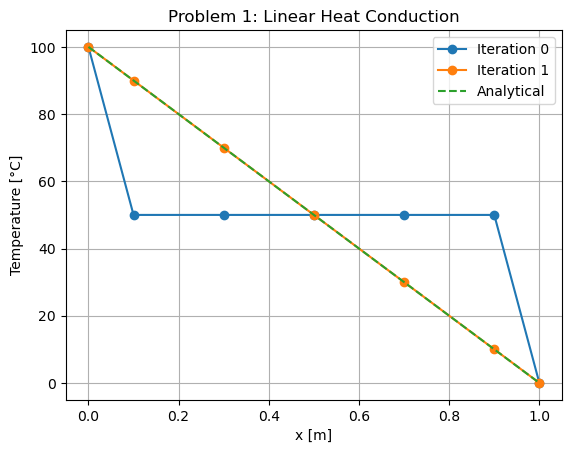

In [21]:
#analytical xolution
T_analytical = T1 + (T2 - T1)*grid.xP/lx
# Plot numerical solution at each iteration
for i, T_iter in enumerate(T_solns):
    plt.plot(grid.xP, T_iter, marker='o', label="Iteration {}".format(i))

# Plot analytical solution
plt.plot(grid.xP, T_analytical, linestyle='--', label="Analytical")

plt.xlabel("x [m]")
plt.ylabel("Temperature [°C]")
plt.title("Problem 1: Linear Heat Conduction")
plt.legend()
plt.grid()
plt.show()

The solution converged in one iteration (for all grid resolutions). This occurs because the problem is linear. the thermal conductivity is constant, the boundary conditions are fixed temperatures, and there are no nonlinear source terms. As a result, the coefficient matrix does not depend on the temperature field, and solving the linear system once gives the converged finite-volume solution.

## Grid Indipendence Study
To determine an appropriate number of control volumes, the problem is solved using several grid resolutions. The numerical solution is compared with the analytical linear solution, and the maximum absolute error is recorded for each grid. The number of iterations required for convergence is also reported.

In [58]:
def solve_problem1(ncv):
    """Solve Problem 1 for a given number of control volumes."""
    
    # Define the grid
    grid = Grid(lx, ly, lz, ncv)
    
    # Define the coefficients
    coeffs = ScalarCoeffs(grid.ncv)

    # Initial condition
    T0 = 50

    # Initialize temperature field
    T = T0*np.ones(grid.ncv+2)
    
    # Define boundary conditions
    west_bc = DirichletBc(T, grid, T1, BoundaryLocation.WEST)
    east_bc = DirichletBc(T, grid, T2, BoundaryLocation.EAST)
    
    # Apply boundary conditions
    west_bc.apply()
    east_bc.apply()
    
    # Define diffusion model
    diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)
    
    # Iterate until convergence
    for i in range(maxIter):
        
        # Zero coefficients and add diffusion contribution
        coeffs.zero()
        coeffs = diffusion.add(coeffs)
        
        # Compute residual
        maxResid = norm(coeffs.rP, np.inf)
        
        # Check convergence
        if maxResid < converged:
            break
        
        # Solve linear system
        dT = solve(coeffs)
        
        # Update solution
        T[1:-1] += dT
        
        # Apply boundary conditions
        west_bc.apply()
        east_bc.apply()
    
    # Analytical solution
    T_analytical = T1 + (T2 - T1)*grid.xP/lx
    
    # Maximum absolute error
    max_error = np.max(np.abs(T - T_analytical))
    
    return grid, T, T_analytical, max_error, i
    # Control volumes used for grid independence study
ncv_values = [5, 10, 20, 40, 80]

# Empty lists to store results
errors = []
iterations = []

# Solve the problem for each grid size
for ncv in ncv_values:
    
    grid_i, T_i, T_analytical_i, error_i, iter_i = solve_problem1(ncv)
    
    errors.append(error_i)
    iterations.append(iter_i)
    
    print("ncv = {}; Max. Error = {}; Iterations = {}".format(ncv, error_i, iter_i))

ncv = 5; Max. Error = 1.4210854715202004e-14; Iterations = 1
ncv = 10; Max. Error = 1.4210854715202004e-14; Iterations = 1
ncv = 20; Max. Error = 2.842170943040401e-14; Iterations = 1
ncv = 40; Max. Error = 4.263256414560601e-14; Iterations = 1
ncv = 80; Max. Error = 1.5631940186722204e-13; Iterations = 1


The grid independence study shows that the numerical solution won't change significantly as the number of control volumes is increased. This is expected because the analytical solution for this problem is linear, and the finite-volume discretization can represent a linear temperature profile accurately. we also obsevre a slight rise in error as the grid number is increased which is because of roun-off error. Therefore, even a relatively coarse grid gives an accurate solution. A grid with 5 control volumes is sufficient for this problem.

## problem 2, Surface Convection Model


we ar3e solving $-k\frac{d^2T}{dx^2} + hA_o(T-T_\infty)=0$ using __finite volume method__ to obtain __temperature distribution__ throughout the bar.


Problem 1 was only conduction. heat enters from one side and leaves from the other side
Problem 2 has conduction plus side convection. heat conducts along x
but also leaks from the side surfaces to air. So the center of the bar becomes cooler than the ends.
Because both ends are fixed at 100.

This code builds upon the previous solution by incorporating external convection. While maintaining the same Dirichlet boundary conditions, it introduces a constant external convection term derived from Newton's law of cooling:

$$ q = hA(T - T_\infty) $$

This convection component is integrated into the discretized equation set as a source term via the SurfaceConvectionModel class, which is provided below.

In [22]:
class SurfaceConvectionModel:
    """Class defining a surface convection model"""
    
    def __init__(self, grid, T, ho, To):
        """Constructor"""
        self._grid = grid
        self._T = T
        self._ho = ho
        self._To = To
        
    def add(self, coeffs):
        """Function to add surface convection terms to coefficient arrays"""
        
        # Calculate the source term
        source = self._ho*self._grid.Ao*(self._T[1:-1] - self._To)
        
        # Calculate the linearization coefficients
        coeffP = self._ho*self._grid.Ao
        
        # Add to coefficient arrays
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_rP(source)
        
        return coeffs

In [73]:
import numpy as np
from numpy.linalg import norm

# Define the grid
lx = 1.0
ly = 0.1
lz = 0.1
ncv = 10

grid = Grid(lx, ly, lz, ncv)

# Set the maximum number of iterations and convergence criterion
maxIter = 100
converged = 1e-6

# Define thermophysical properties
k = 21.9

# Define convection parameters
ho = 12
To = 25

# Define boundary temperatures
T1 = 100
T2 = 100


# Define the coefficients
coeffs = ScalarCoeffs(grid.ncv)

# Initial conditions
T0 = 100

# Initialize field variable arrays
T = T0*np.ones(grid.ncv+2)

# Define boundary conditions
west_bc = DirichletBc(T, grid, T1, BoundaryLocation.WEST)
east_bc = DirichletBc(T, grid, T2, BoundaryLocation.EAST)

# Apply boundary conditions
west_bc.apply()
east_bc.apply()

# Create list to store the solutions at each iteration
T_solns = [np.copy(T)]

# Define the diffusion model
diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)

# Define the surface convection model
surfaceConvection = SurfaceConvectionModel(grid, T, ho, To)

# Iterate until the solution is converged
for i in range(maxIter):
    # Zero the coefficients and add each influence
    coeffs.zero()
    coeffs = diffusion.add(coeffs)
    coeffs = surfaceConvection.add(coeffs)

    # Compute residual and check for convergence 
    maxResid = norm(coeffs.rP, np.inf)
    avgResid = np.mean(np.absolute(coeffs.rP))
    print("Iteration = {}; Max. Resid. = {}; Avg. Resid. = {}".format(i, maxResid, avgResid))
    if maxResid < converged:
        break
    
    # Solve the sparse matrix system
    dT = solve(coeffs)
    
    # Update the solution and boundary conditions
    T[1:-1] += dT
    west_bc.apply()
    east_bc.apply()
    
    # Store the solution
    T_solns.append(np.copy(T))

Iteration = 0; Max. Resid. = 36.00000000000001; Avg. Resid. = 36.00000000000001
Iteration = 1; Max. Resid. = 6.750155989720952e-14; Avg. Resid. = 2.5934809855243656e-14


as we can see, The solution converged in one iteration again, because the governing equation and the convection term are both linear in temperature, allowing the finite-volume system to reach the converged solution immediately after solving the linear system once.

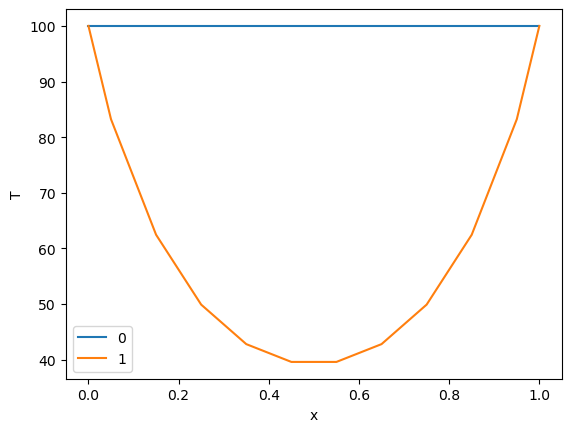

In [74]:
%matplotlib inline
import matplotlib.pyplot as plt

i = 0
for T in T_solns:
    plt.plot(grid.xP, T, label=str(i))
    i += 1

plt.xlabel("x")
plt.ylabel("T")
plt.legend()
plt.show()

In [71]:
# Analytical solution for external convection
A = ly*lz
P = 2*(ly + lz)

m = np.sqrt(ho*P/(k*A))

theta_b = T1 - To
x_exact = np.linspace(0, lx, 200)
T_analytical = To + theta_b*np.cosh(m*(x_exact - lx/2))/np.cosh(m*lx/2)

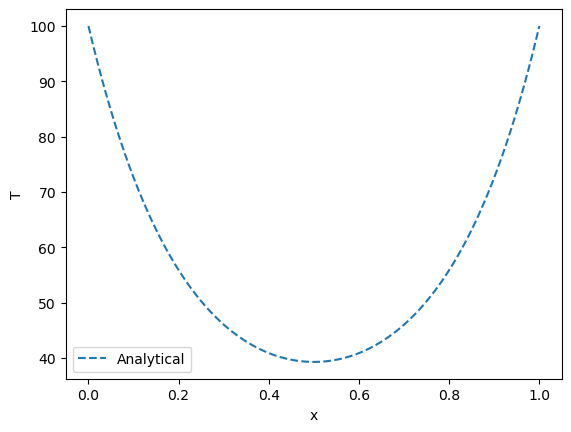

In [72]:
plt.plot(x_exact, T_analytical, linestyle='--', label="Analytical")

plt.xlabel("x")
plt.ylabel("T")
plt.legend()
plt.show()

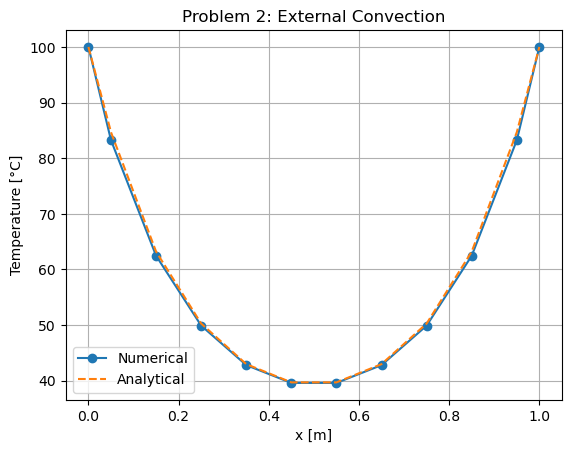

In [31]:
plt.plot(grid.xP, T, marker='o', label="Numerical")
plt.plot(grid.xP, T_analytical, linestyle='--', label="Analytical")

plt.xlabel("x [m]")
plt.ylabel("Temperature [°C]")
plt.title("Problem 2: External Convection")
plt.legend()
plt.grid()
plt.show()

The numerical and analytical solutions overlap almost perfectly, indicating that the finite-volume implementation accurately captures the conduction and convection physics of the problem. 

# problem 3, Internal Heat Generation


we are solving $-k\frac{d^2T}{dx^2}=q'''$ using __finite volume method__ to obtain __temperature distribution__ throughout the wall (including the surface temperatures, the maximum temperature, and the location of the maximum temperature).


For steady one-dimensional conduction with uniform internal heat generation, the governing equation is:

$$
-k\frac{d^2T}{dx^2} = q'''
$$

or equivalently,

$$
\frac{d^2T}{dx^2} = -\frac{q'''}{k}
$$

Therefore, unlike Problems 1 and 2, the temperature profile is curved rather than linear.

in problem 3, the boundary condition is neither Drichlet or Neumann. there is no fixed surface termerature and no temperature gradient is directrly spesified. 
Instead, both sides have convection.
That means the boundary condition is a Robin boundary condition:

In [32]:
class RobinBc:
    """Class defining a convection boundary condition"""
    
    def __init__(self, phi, grid, h, Tinf, k, loc):
        """Constructor
            phi ..... field variable array
            grid .... grid
            h ....... convection coefficient [W/m2.K]
            Tinf .... ambient temperature [C]
            k ....... thermal conductivity [W/m.K]
            loc ..... boundary location
        """
        self._phi = phi
        self._grid = grid
        self._h = h
        self._Tinf = Tinf
        self._k = k
        self._loc = loc
        
    def value(self):
        """Return the boundary value using linear extrapolation with convection"""
        
        if self._loc is BoundaryLocation.WEST:
            dx = self._grid.dx_WP[0]
            return (self._k*self._phi[1]/dx + self._h*self._Tinf)/(self._k/dx + self._h)
        
        elif self._loc is BoundaryLocation.EAST:
            dx = self._grid.dx_PE[-1]
            return (self._k*self._phi[-2]/dx + self._h*self._Tinf)/(self._k/dx + self._h)
        
        else:
            raise ValueError("Unknown boundary location")
            
    def coeff(self):
        """Return the linearization coefficient"""
        
        if self._loc is BoundaryLocation.WEST:
            dx = self._grid.dx_WP[0]
            return (self._k/dx)/(self._k/dx + self._h)
        
        elif self._loc is BoundaryLocation.EAST:
            dx = self._grid.dx_PE[-1]
            return (self._k/dx)/(self._k/dx + self._h)
        
        else:
            raise ValueError("Unknown boundary location")
    
    def apply(self):
        """Apply the boundary condition"""
        
        if self._loc is BoundaryLocation.WEST:
            self._phi[0] = self.value()
        
        elif self._loc is BoundaryLocation.EAST:
            self._phi[-1] = self.value()
        
        else:
            raise ValueError("Unknown boundary location")

# heat generation model
note that in our formulation, terms like convection loss are positive residual terms. Heat generation is opposite to heat loss, so it is added with a negative sign.

In [33]:
class HeatGenerationModel:
    """Class defining a uniform volumetric heat generation model"""
    
    def __init__(self, grid, qdot):
        """Constructor
            grid .... grid
            qdot .... volumetric heat generation rate [W/m3]
        """
        self._grid = grid
        self._qdot = qdot
        
    def add(self, coeffs):
        """Function to add heat generation source term to coefficient arrays"""
        
        # Heat generation acts as a source term in each control volume
        source = -self._qdot*self._grid.vol
        
        # Add source term to residual array
        coeffs.accumulate_rP(source)
        
        return coeffs

numerical solution

In [98]:
# Geometry
lx = 0.1
ly = 1.0
lz = 1.0
ncv = 40

# Properties
k = 26
qdot = 50000

# Convection
h = 280
Tinf_west = 50
Tinf_east = 40
ly = 1.0
lz = 1.0
# Define the grid
grid = Grid(lx, ly, lz, ncv)

# Solver settings
maxIter = 100
converged = 1e-6

# Define coefficients
coeffs = ScalarCoeffs(grid.ncv)

# Initial condition
T0 = 45
T = T0*np.ones(grid.ncv+2)

# Define convection boundary conditions
west_bc = RobinBc(T, grid, h, Tinf_west, k, BoundaryLocation.WEST)
east_bc = RobinBc(T, grid, h, Tinf_east, k, BoundaryLocation.EAST)

# Apply boundary conditions
west_bc.apply()
east_bc.apply()

# Store solutions
T_solns = [np.copy(T)]

# Define models
diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)
heatGeneration = HeatGenerationModel(grid, qdot)

# Iterate until convergence
for i in range(maxIter):
    
    # Zero coefficients and add physical models
    coeffs.zero()
    coeffs = diffusion.add(coeffs)
    coeffs = heatGeneration.add(coeffs)

    # Compute residual
    maxResid = norm(coeffs.rP, np.inf)
    avgResid = np.mean(np.absolute(coeffs.rP))
    
    print("Iteration = {}; Max. Resid. = {}; Avg. Resid. = {}".format(i, maxResid, avgResid))
    
    if maxResid < converged:
        break
    
    # Solve linear system
    dT = solve(coeffs)
    
    # Update temperature
    T[1:-1] += dT
    
    # Apply boundary conditions
    west_bc.apply()
    east_bc.apply()
    
    # Store solution
    T_solns.append(np.copy(T))
    

Iteration = 0; Max. Resid. = 1506.4041745731288; Avg. Resid. = 187.82020872865274
Iteration = 1; Max. Resid. = 1.7598722479306161e-10; Avg. Resid. = 5.677804892911809e-11


Since the governing equation, heat generation term, and convection boundary conditions are all linear, The solution converged in one iteration. the finite-volume system reaches the converged solution immediately after solving the linear system once.

# analyticla Solution

In [99]:
# Analytical solution for Problem 3

L = lx

# T(x) = -qdot/(2k)*x^2 + C1*x + C2
# dT/dx = -qdot/k*x + C1

A_mat = np.array([
    [k, -h],
    [k + h*L, h]
])

b_vec = np.array([
    -h*Tinf_west,
    qdot*L + h*qdot*L**2/(2*k) + h*Tinf_east
])

C1, C2 = np.linalg.solve(A_mat, b_vec)


T_analytical = -qdot/(2*k)*grid.xP**2 + C1*grid.xP + C2

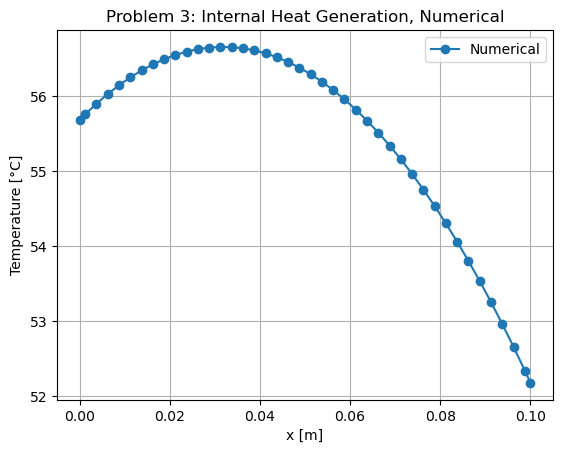

In [100]:
plt.plot(grid.xP, T, marker='o', label="Numerical")
plt.xlabel("x [m]")
plt.ylabel("Temperature [°C]")
plt.title("Problem 3: Internal Heat Generation, Numerical")
plt.legend()
plt.grid()
plt.show()

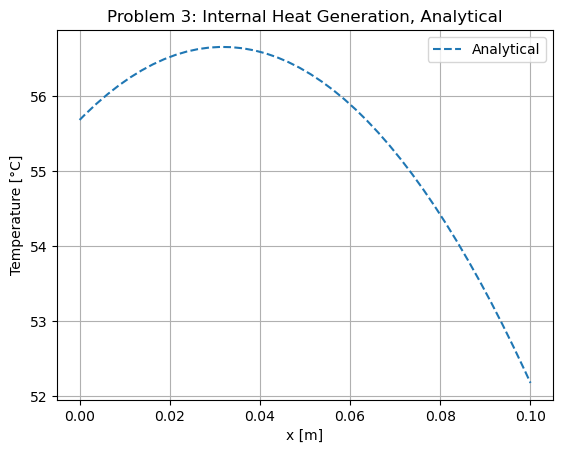

In [101]:
plt.plot(grid.xP, T_analytical, linestyle='--', label="Analytical")
plt.xlabel("x [m]")
plt.ylabel("Temperature [°C]")
plt.title("Problem 3: Internal Heat Generation, Analytical")
plt.legend()
plt.grid()
plt.show()

In [102]:
T_surface_west = T[0]
T_surface_east = T[-1]

T_max = np.max(T)
x_max = grid.xP[np.argmax(T)]

print("West surface temperature = {:.4f} °C".format(T_surface_west))
print("East surface temperature = {:.4f} °C".format(T_surface_east))
print("Maximum temperature = {:.4f} °C".format(T_max))
print("Location of maximum temperature = {:.4f} m".format(x_max))

West surface temperature = 55.6786 °C
East surface temperature = 52.1786 °C
Maximum temperature = 56.6521 °C
Location of maximum temperature = 0.0312 m


In [103]:
x_max_analytical = k*C1/qdot
T_max_analytical = -qdot/(2*k)*x_max_analytical**2 + C1*x_max_analytical + C2

T_surface_west_analytical = C2
T_surface_east_analytical = -qdot/(2*k)*L**2 + C1*L + C2

print("Analytical west surface temperature = {:.4f} °C".format(T_surface_west_analytical))
print("Analytical east surface temperature = {:.4f} °C".format(T_surface_east_analytical))
print("Analytical maximum temperature = {:.4f} °C".format(T_max_analytical))
print("Analytical location of maximum temperature = {:.4f} m".format(x_max_analytical))

Analytical west surface temperature = 55.6786 °C
Analytical east surface temperature = 52.1786 °C
Analytical maximum temperature = 56.6509 °C
Analytical location of maximum temperature = 0.0318 m


# Grid independence

In [104]:
ncv_values = [5, 10, 20, 40, 80]

errors = []
iterations = []
west_surface_temperatures = []
east_surface_temperatures = []
maximum_temperatures = []
maximum_locations = []

for ncv in ncv_values:
    
    grid_i, T_i, T_analytical_i, error_i, iter_i, Tw_i, Te_i, Tmax_i, xmax_i = solve_problem3(ncv)
    
    errors.append(error_i)
    iterations.append(iter_i)
    west_surface_temperatures.append(Tw_i)
    east_surface_temperatures.append(Te_i)
    maximum_temperatures.append(Tmax_i)
    maximum_locations.append(xmax_i)
    
    print("ncv = {}; Max. Error = {:.6e}; Tw = {:.4f}; Te = {:.4f}; Tmax = {:.4f}; x_max = {:.4f}; Iterations = {}".format(
        ncv, error_i, Tw_i, Te_i, Tmax_i, xmax_i, iter_i
    ))

ncv = 5; Max. Error = 9.615385e-02; Tw = 55.6786; Te = 52.1786; Tmax = 56.7440; x_max = 0.0300; Iterations = 1
ncv = 10; Max. Error = 2.403846e-02; Tw = 55.6786; Te = 52.1786; Tmax = 56.6651; x_max = 0.0350; Iterations = 1
ncv = 20; Max. Error = 6.009615e-03; Tw = 55.6786; Te = 52.1786; Tmax = 56.6565; x_max = 0.0325; Iterations = 1
ncv = 40; Max. Error = 1.502404e-03; Tw = 55.6786; Te = 52.1786; Tmax = 56.6521; x_max = 0.0312; Iterations = 1
ncv = 80; Max. Error = 3.756010e-04; Tw = 55.6786; Te = 52.1786; Tmax = 56.6513; x_max = 0.0319; Iterations = 1


grid independece study shows that as we add more grid cells, our results get closer to the exact analytical answer. The error drops as the mesh gets finer, which confirms the model is working correctly.

The temperatures on the west and east sides barely change, even when we switch grid sizes, so they aren't very sensitive to the mesh. The peak temperature and its location also level off as the grid gets finer.

Using 20 to 40 cells is plenty. Anything more just slows down the calculation without giving us a better result.

Because the math is linear, the model finishes in just one iteration. Since the conductivity, convection, and heat generation are all constant, the system doesn't need to account for any complex, nonlinear changes.

# Problem 4, Radiation Heat Loss


we are solving $-k\frac{d^2T}{dx^2} + \epsilon \sigma (T^4-T_\infty^4)=0$ with both implicit and explicit linearization, using __finite volume method__ to obtain __temperature distribution__ throughout the steel/wood bar.

# Physics
The side surfaces lose heat through radiation, defined by the equation:$$q'' = \epsilon \sigma (T^4 - T_\infty^4)$$Given that $T_\infty = 0 \text{ K}$, this simplifies to:$$q'' = \epsilon \sigma T^4$$Where:$\epsilon = 1$$\sigma = 5.67 \times 10^{-8}$



In this problem, heat is lost from the exposed surfaces of the square bar by thermal radiation. Unlike convection, radiation heat transfer depends on the fourth power of temperature, making the governing equation nonlinear.

Two different linearization approaches are considered:

1. Explicit linearization, where the radiation source term is added only to the residual.
2. Implicit linearization, where the derivative of the radiation source term is also added to the Jacobian matrix.

The problem is solved for both steel and wood in order to investigate the effect of thermal conductivity on the nonlinear solution behavior.

# Radiation model (explicit)

In [48]:
class RadiationModelExplicit:
    """Explicit radiation source model"""
    
    def __init__(self, grid, T, eps, sigma, Tsur):
        
        self._grid = grid
        self._T = T
        self._eps = eps
        self._sigma = sigma
        self._Tsur = Tsur
        
    def add(self, coeffs):
        
        # Radiation source term
        source = self._eps*self._sigma*self._grid.Ao*(self._T[1:-1]**4 - self._Tsur**4)
        
        # Add only to residual
        coeffs.accumulate_rP(source)
        
        return coeffs

# Radiation model (implicit)

In [49]:
class RadiationModelImplicit:
    """Implicit radiation source model"""
    
    def __init__(self, grid, T, eps, sigma, Tsur):
        
        self._grid = grid
        self._T = T
        self._eps = eps
        self._sigma = sigma
        self._Tsur = Tsur
        
    def add(self, coeffs):
        
        # Radiation source term
        source = self._eps*self._sigma*self._grid.Ao*(self._T[1:-1]**4 - self._Tsur**4)
        
        # Linearization coefficient
        coeffP = 4*self._eps*self._sigma*self._grid.Ao*self._T[1:-1]**3
        
        # Add to coefficients
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_rP(source)
        
        return coeffs

# general solver

In [50]:
def solve_problem4(k, cp, radiationModelType, ncv):
    
    # Geometry
    lx = 1.0
    ly = 0.1
    lz = 0.1
    
    # Grid
    grid = Grid(lx, ly, lz, ncv)
    
    # Solver settings
    maxIter = 500
    converged = 1e-6
    
    # Radiation parameters
    eps = 1.0
    sigma = 5.67e-8
    Tsur = 0.0
    
    # Boundary temperatures
    T1 = 400
    T2 = 0
    
    # Coefficients
    coeffs = ScalarCoeffs(grid.ncv)
    
    # Initial condition
    T0 = 200
    T = T0*np.ones(grid.ncv+2)
    
    # Boundary conditions
    west_bc = DirichletBc(T, grid, T1, BoundaryLocation.WEST)
    east_bc = DirichletBc(T, grid, T2, BoundaryLocation.EAST)
    
    west_bc.apply()
    east_bc.apply()
    
    # Diffusion model
    diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)
    
    # Radiation model
    radiation = radiationModelType(grid, T, eps, sigma, Tsur)
    
    # Iteration loop
    for i in range(maxIter):
        
        coeffs.zero()
        
        coeffs = diffusion.add(coeffs)
        coeffs = radiation.add(coeffs)
        
        maxResid = norm(coeffs.rP, np.inf)
        
        if maxResid < converged:
            break
        
        dT = solve(coeffs)
        
        T[1:-1] += dT
        
        west_bc.apply()
        east_bc.apply()
    
    return grid, T, i, maxResid
    

In [106]:
ncv = 40

# Steel
k_steel = 60
cp_steel = 430

# Wood
k_wood = 0.1
cp_wood = 1.3

# Steel explicit
grid_se, T_se, iter_se, resid_se = solve_problem4(
    k_steel, cp_steel, RadiationModelExplicit, ncv
)

# Steel implicit
grid_si, T_si, iter_si, resid_si = solve_problem4(
    k_steel, cp_steel, RadiationModelImplicit, ncv
)

# Wood explicit
grid_we, T_we, iter_we, resid_we = solve_problem4(
    k_wood, cp_wood, RadiationModelExplicit, ncv
)

# Wood implicit
grid_wi, T_wi, iter_wi, resid_wi = solve_problem4(
    k_wood, cp_wood, RadiationModelImplicit, ncv
)

C:\Users\smohsen7\AppData\Local\Temp\ipykernel_21872\547135727.py:15: RuntimeWarning: overflow encountered in power
  source = self._eps*self._sigma*self._grid.Ao*(self._T[1:-1]**4 - self._Tsur**4)


The error occurring when running the cell above is due to the divergence of the explicit solution, which we will discuss shortly.

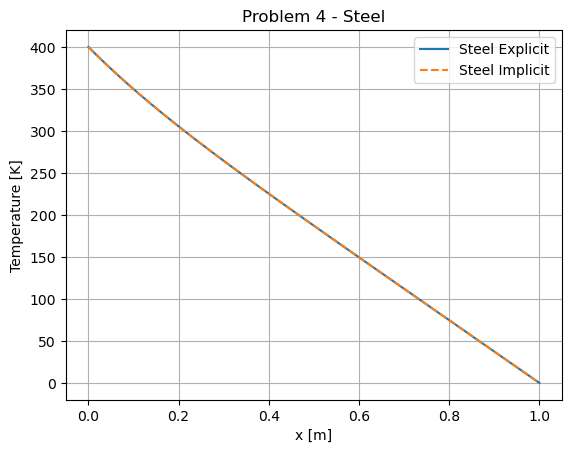

In [52]:
plt.plot(grid_se.xP, T_se, label="Steel Explicit")
plt.plot(grid_si.xP, T_si, linestyle='--', label="Steel Implicit")

plt.xlabel("x [m]")
plt.ylabel("Temperature [K]")
plt.title("Problem 4 - Steel")
plt.legend()
plt.grid()
plt.show()

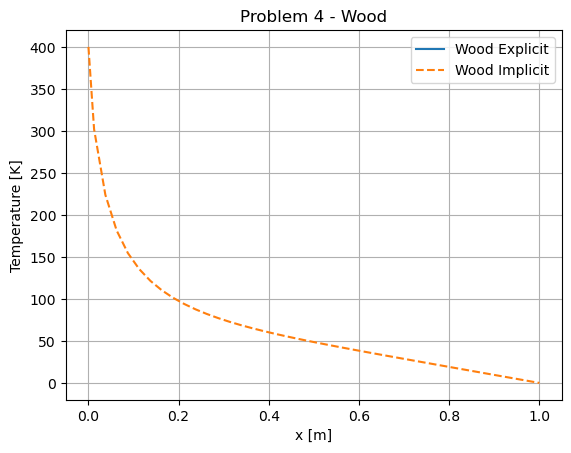

In [56]:
plt.plot(grid_we.xP, T_we, label="Wood Explicit")
plt.plot(grid_wi.xP, T_wi, linestyle='--', label="Wood Implicit")

plt.xlabel("x [m]")
plt.ylabel("Temperature [K]")
plt.title("Problem 4 - Wood")
plt.legend()
plt.grid()
plt.show()

In [53]:
print("Steel Explicit Iterations =", iter_se)
print("Steel Implicit Iterations =", iter_si)

print("Wood Explicit Iterations =", iter_we)
print("Wood Implicit Iterations =", iter_wi)

Steel Explicit Iterations = 10
Steel Implicit Iterations = 3
Wood Explicit Iterations = 499
Wood Implicit Iterations = 7


The radiation problem is nonlinear because the radiation heat flux depends on the fourth power of temperature. As a result, iterative solution methods are required.

The implicit linearization converged more robustly and generally required fewer iterations than the explicit implementation. This occurs because the implicit method includes the derivative of the radiation source term in the Jacobian matrix, improving numerical stability and coupling between the temperature field and the nonlinear radiation losses.

The effect of nonlinear radiation is stronger for wood because of its low thermal conductivity. Since heat conduction inside the material is weak, radiation losses produce stronger temperature gradients and more nonlinear behavior. Steel, with its higher thermal conductivity, distributes heat more effectively and therefore exhibits smoother temperature variations and improved convergence behavior.